# Exploratory Data Analysis

### Import modules and data

In [2]:
%pip install esda

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import libpysal
import esda
import matplotlib.patches as mpatches
import math

In [4]:
# data import
DATA_PATH = "../data/merged_ecec_province.geojson"
gdf = gpd.read_file(DATA_PATH)

### Check dataframe dimensions and variables' distributions

In [5]:
print(f"The dataframe has dimensions {gdf.shape}") # 107 provinces, 63 variables
print(f"The dataframe has {gdf.select_dtypes(include='number').shape[1]} numerical variables") # 47 actual variables

nan_cols = gdf.select_dtypes(exclude='number').columns # only codes and names in non-numeric
print(f"The non numerical columns are: {nan_cols.tolist()}")
print("\tNon-numerical are just codes and names")

The dataframe has dimensions (107, 63)
The dataframe has 47 numerical variables
The non numerical columns are: ['geo_point_2d', 'year', 'rip_code', 'rip_name', 'reg_code', 'reg_name', 'prov_code', 'prov_name', 'prov_name_upper', 'prov_name_lower', 'prov_area_code', 'prov_type', 'prov_sigla', 'join_key', 'prov', 'geometry']
	Non-numerical are just codes and names


In [6]:
summary = (
    gdf.select_dtypes(include='number').describe()
        .T[['mean', 'std', 'min', 'max']].round(2)
)

print(summary)

                                         mean        std       min         max
fem_empl_rate                           51.45      12.41     20.80       69.10
population                          551683.49  602448.84  80564.00  4216874.00
unempl_rate                              8.45       4.45      2.30       21.50
part_rate                                0.05       0.01      0.03        0.06
empl_rate                               60.50       9.90     35.80       74.10
empl_growth                              2.32       3.35     -4.76       17.65
inact_rate                              34.26       8.30     23.50       55.50
fem_edu_rate                             0.18       0.03      0.12        0.27
male_edu_rate                            0.15       0.03      0.08        0.25
service_empl_rate                        0.67       0.07      0.52        0.87
GDP                                      0.03       0.01      0.02        0.07
n_large_comp                             0.10       

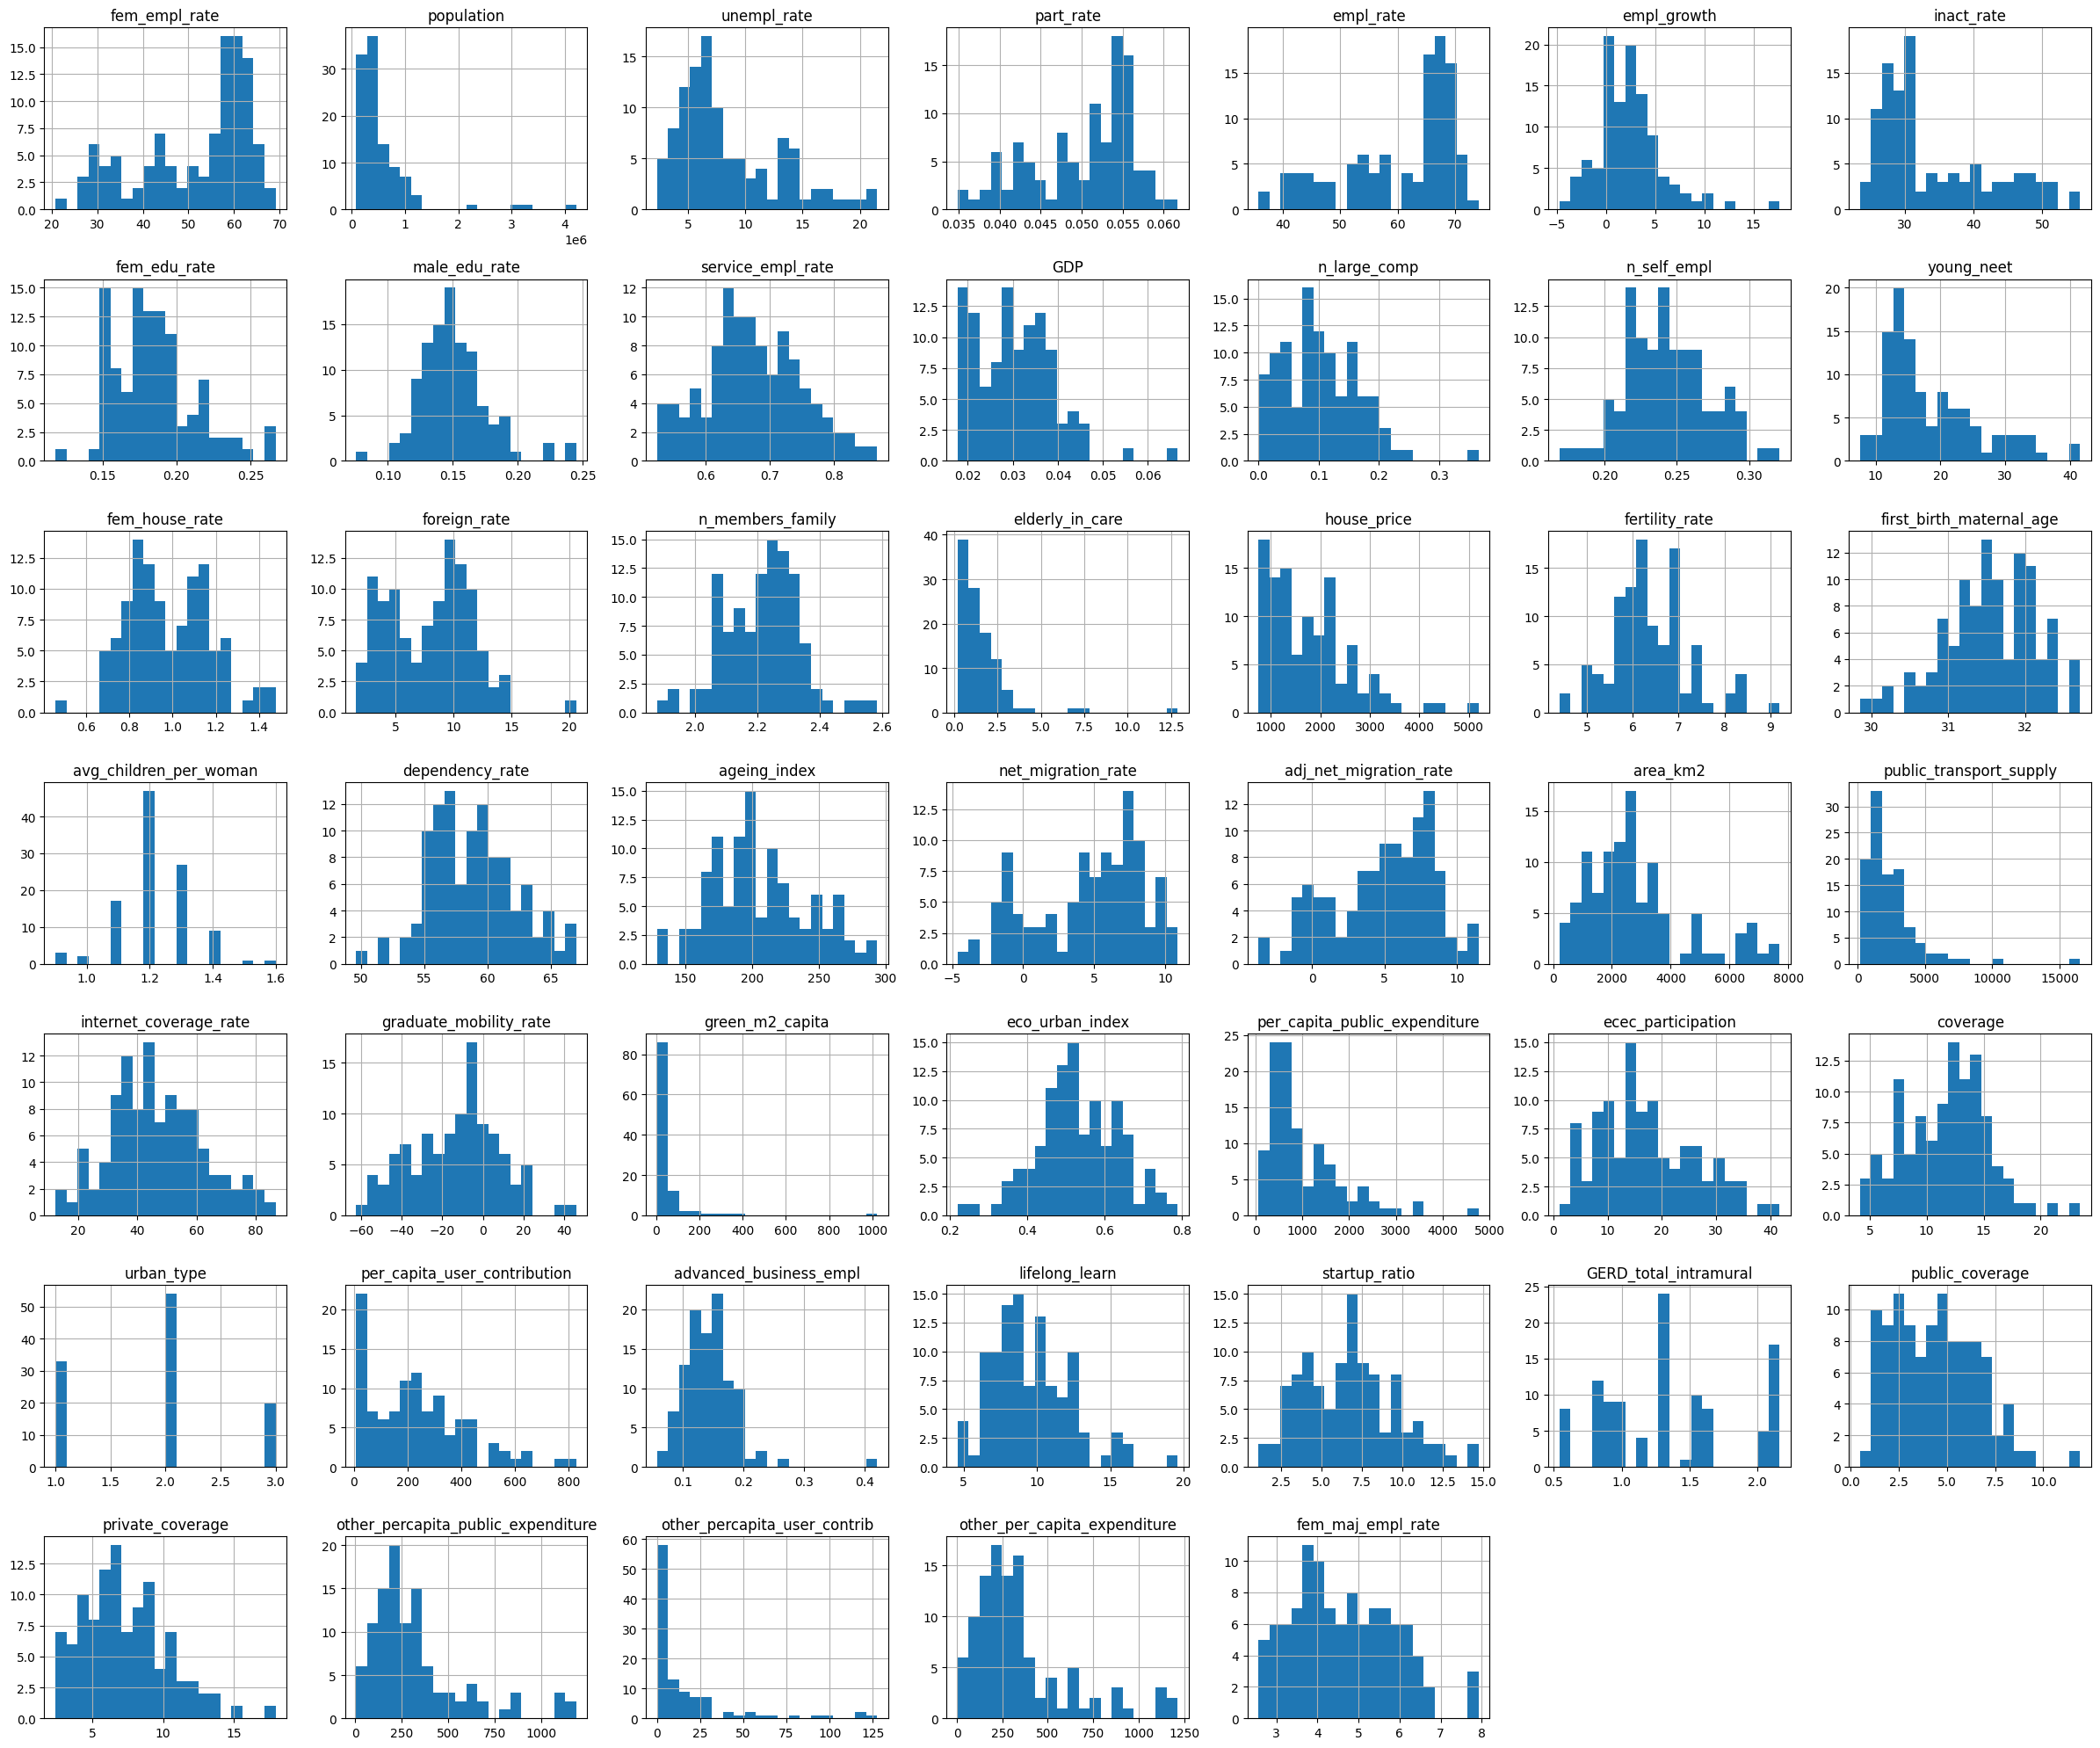

In [7]:
gdf.hist(figsize=(24, 20), bins=20)
plt.tight_layout()
plt.show()

### Correlation Analysis

In [8]:
gdf.select_dtypes('number').corr(method='spearman').style.background_gradient(cmap='coolwarm')

,fem_empl_rate,population,unempl_rate,part_rate,empl_rate,empl_growth,inact_rate,fem_edu_rate,male_edu_rate,service_empl_rate,GDP,n_large_comp,n_self_empl,young_neet,fem_house_rate,foreign_rate,n_members_family,elderly_in_care,house_price,fertility_rate,first_birth_maternal_age,avg_children_per_woman,dependency_rate,ageing_index,net_migration_rate,adj_net_migration_rate,area_km2,public_transport_supply,internet_coverage_rate,graduate_mobility_rate,green_m2_capita,eco_urban_index,per_capita_public_expenditure,ecec_participation,coverage,urban_type,per_capita_user_contribution,advanced_business_empl,lifelong_learn,startup_ratio,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate
fem_empl_rate,1.000000,0.031276,-0.825909,0.928772,0.966557,0.142978,-0.953271,0.309525,0.220595,-0.266683,0.838730,0.578992,-0.448141,-0.824985,-0.823515,0.707173,-0.458623,0.463137,0.609480,-0.219929,0.246143,0.002185,0.405636,0.173715,0.746412,0.719773,-0.072256,0.331530,0.055620,0.803494,0.410524,0.589154,0.751783,0.715655,0.720076,0.060944,0.820782,0.642353,0.572490,0.250337,0.555116,0.561191,0.547589,0.325122,0.415965,0.360689,-0.142911
population,0.031276,1.000000,-0.034929,0.145712,0.067530,0.110268,-0.049921,0.224338,0.333735,0.104720,0.259517,0.416225,-0.214101,-0.091800,-0.264886,0.124630,0.276592,-0.066161,0.489183,0.446802,0.017664,0.320057,-0.447770,-0.536700,-0.036286,-0.008368,0.358647,0.557967,0.321329,0.314613,-0.102342,-0.021599,0.029477,-0.058738,-0.032348,-0.432880,-0.023257,0.418552,0.047367,0.224330,0.034496,-0.276730,0.137851,-0.043055,0.034069,-0.031672,0.350056
unempl_rate,-0.825909,-0.034929,1.000000,-0.800241,-0.865387,-0.107669,0.748986,-0.156348,-0.085187,0.446237,-0.806482,-0.548096,0.387124,0.824471,0.728629,-0.673527,0.265989,-0.466809,-0.553148,0.119134,-0.155203,-0.123100,-0.291827,-0.053109,-0.643462,-0.612218,0.077059,-0.291947,0.083447,-0.679684,-0.319402,-0.598679,-0.551809,-0.558613,-0.643399,-0.086614,-0.656018,-0.593136,-0.393227,-0.192530,-0.452024,-0.384518,-0.577175,-0.253311,-0.378448,-0.285296,0.298699
part_rate,0.928772,0.145712,-0.800241,1.000000,0.955968,0.192054,-0.953640,0.331707,0.254727,-0.315080,0.857805,0.593856,-0.428329,-0.808420,-0.884490,0.792325,-0.296078,0.453373,0.655557,-0.098676,0.234509,0.085619,0.234337,0.006353,0.759970,0.735091,-0.071583,0.369023,0.094488,0.832111,0.373956,0.524586,0.704883,0.692780,0.658565,0.004940,0.776828,0.671242,0.550842,0.225677,0.541055,0.492045,0.509641,0.291062,0.456988,0.323772,-0.195625
empl_rate,0.966557,0.067530,-0.865387,0.955968,1.000000,0.158543,-0.969789,0.289758,0.209458,-0.327454,0.862593,0.602545,-0.441268,-0.844505,-0.833301,0.755499,-0.408213,0.489043,0.636718,-0.175160,0.208224,0.069589,0.379912,0.134837,0.773980,0.743145,-0.061980,0.346265,0.039847,0.809459,0.379642,0.582997,0.726573,0.697769,0.694180,0.072865,0.792570,0.650907,0.555420,0.218571,0.561272,0.531507,0.526950,0.316847,0.410241,0.350617,-0.195541
empl_growth,0.142978,0.110268,-0.107669,0.192054,0.158543,1.000000,-0.157955,0.004400,0.035129,0.052515,0.094671,-0.064491,0.051796,-0.103778,-0.142945,0.026649,0.106060,0.040646,0.175418,0.100416,0.058074,0.138196,-0.077739,-0.074738,0.061807,0.078573,-0.089937,0.023931,0.083307,0.066646,-0.172474,-0.089636,0.114133,0.083393,-0.002305,-0.141719,0.030960,-0.002923,0.099189,-0.137713,-0.018668,0.032039,-0.012341,0.140537,0.055104,0.133582,-0.025628
inact_rate,-0.953271,-0.049921,0.748986,-0.953640,-0.969789,-0.157955,1.000000,-0.319067,-0.242993,0.259336,-0.822604,-0.571853,0.439498,0.792975,0.811357,-0.750909,0.464089,-0.452788,-0.626308,0.234186,-0.229066,-0.006603,-0.432334,-0.204518,-0.802063,-0.776503,0.073317,-0.330153,-0.067577,-0.816700,-0.387343,-0.542470,-0.766133,-0.723894,-0.688109,-0.051183,-0.820919,-0.625236,-0.591517,-0.216135,-0.585633,-0.586758,-0.484100,-0.325117,-0.404654,-0.357824,0.172537
fem_edu_rate,0.30952

### Focus on subset of relevant variables

Some variables have stronger theoretical underpinnings. Thus, I will inspect these in greater detail:
- female employment rate
- unemployment rate
- fem_edu_rate
- GDP
- service_empl_rate 
- avg_children_per_woman
- dependency_rate
- graduate_mobility_rate
- per_capita_public_expenditure
- ecec_participation
- coverage
- per_capita_user_contribution
- fem_maj_empl_rate

In [ ]:
var_subset = [
    'prov_name',
    'rip_name',
    'fem_empl_rate', 
    'unemp_rate', 
    'fem_edu_rate',
    'gdp',
    'service_empl_rate', 
    'dependency_rate',
    'graduate_mobility_rate',
    'per_capita_public_expenditure',
    'ecec_participation',
    'coverage',
    'per_capita_user_contribution',
    'fem_maj_empl_rate']

gdf_subset = gdf[[col for col in gdf.columns if col in var_subset]]



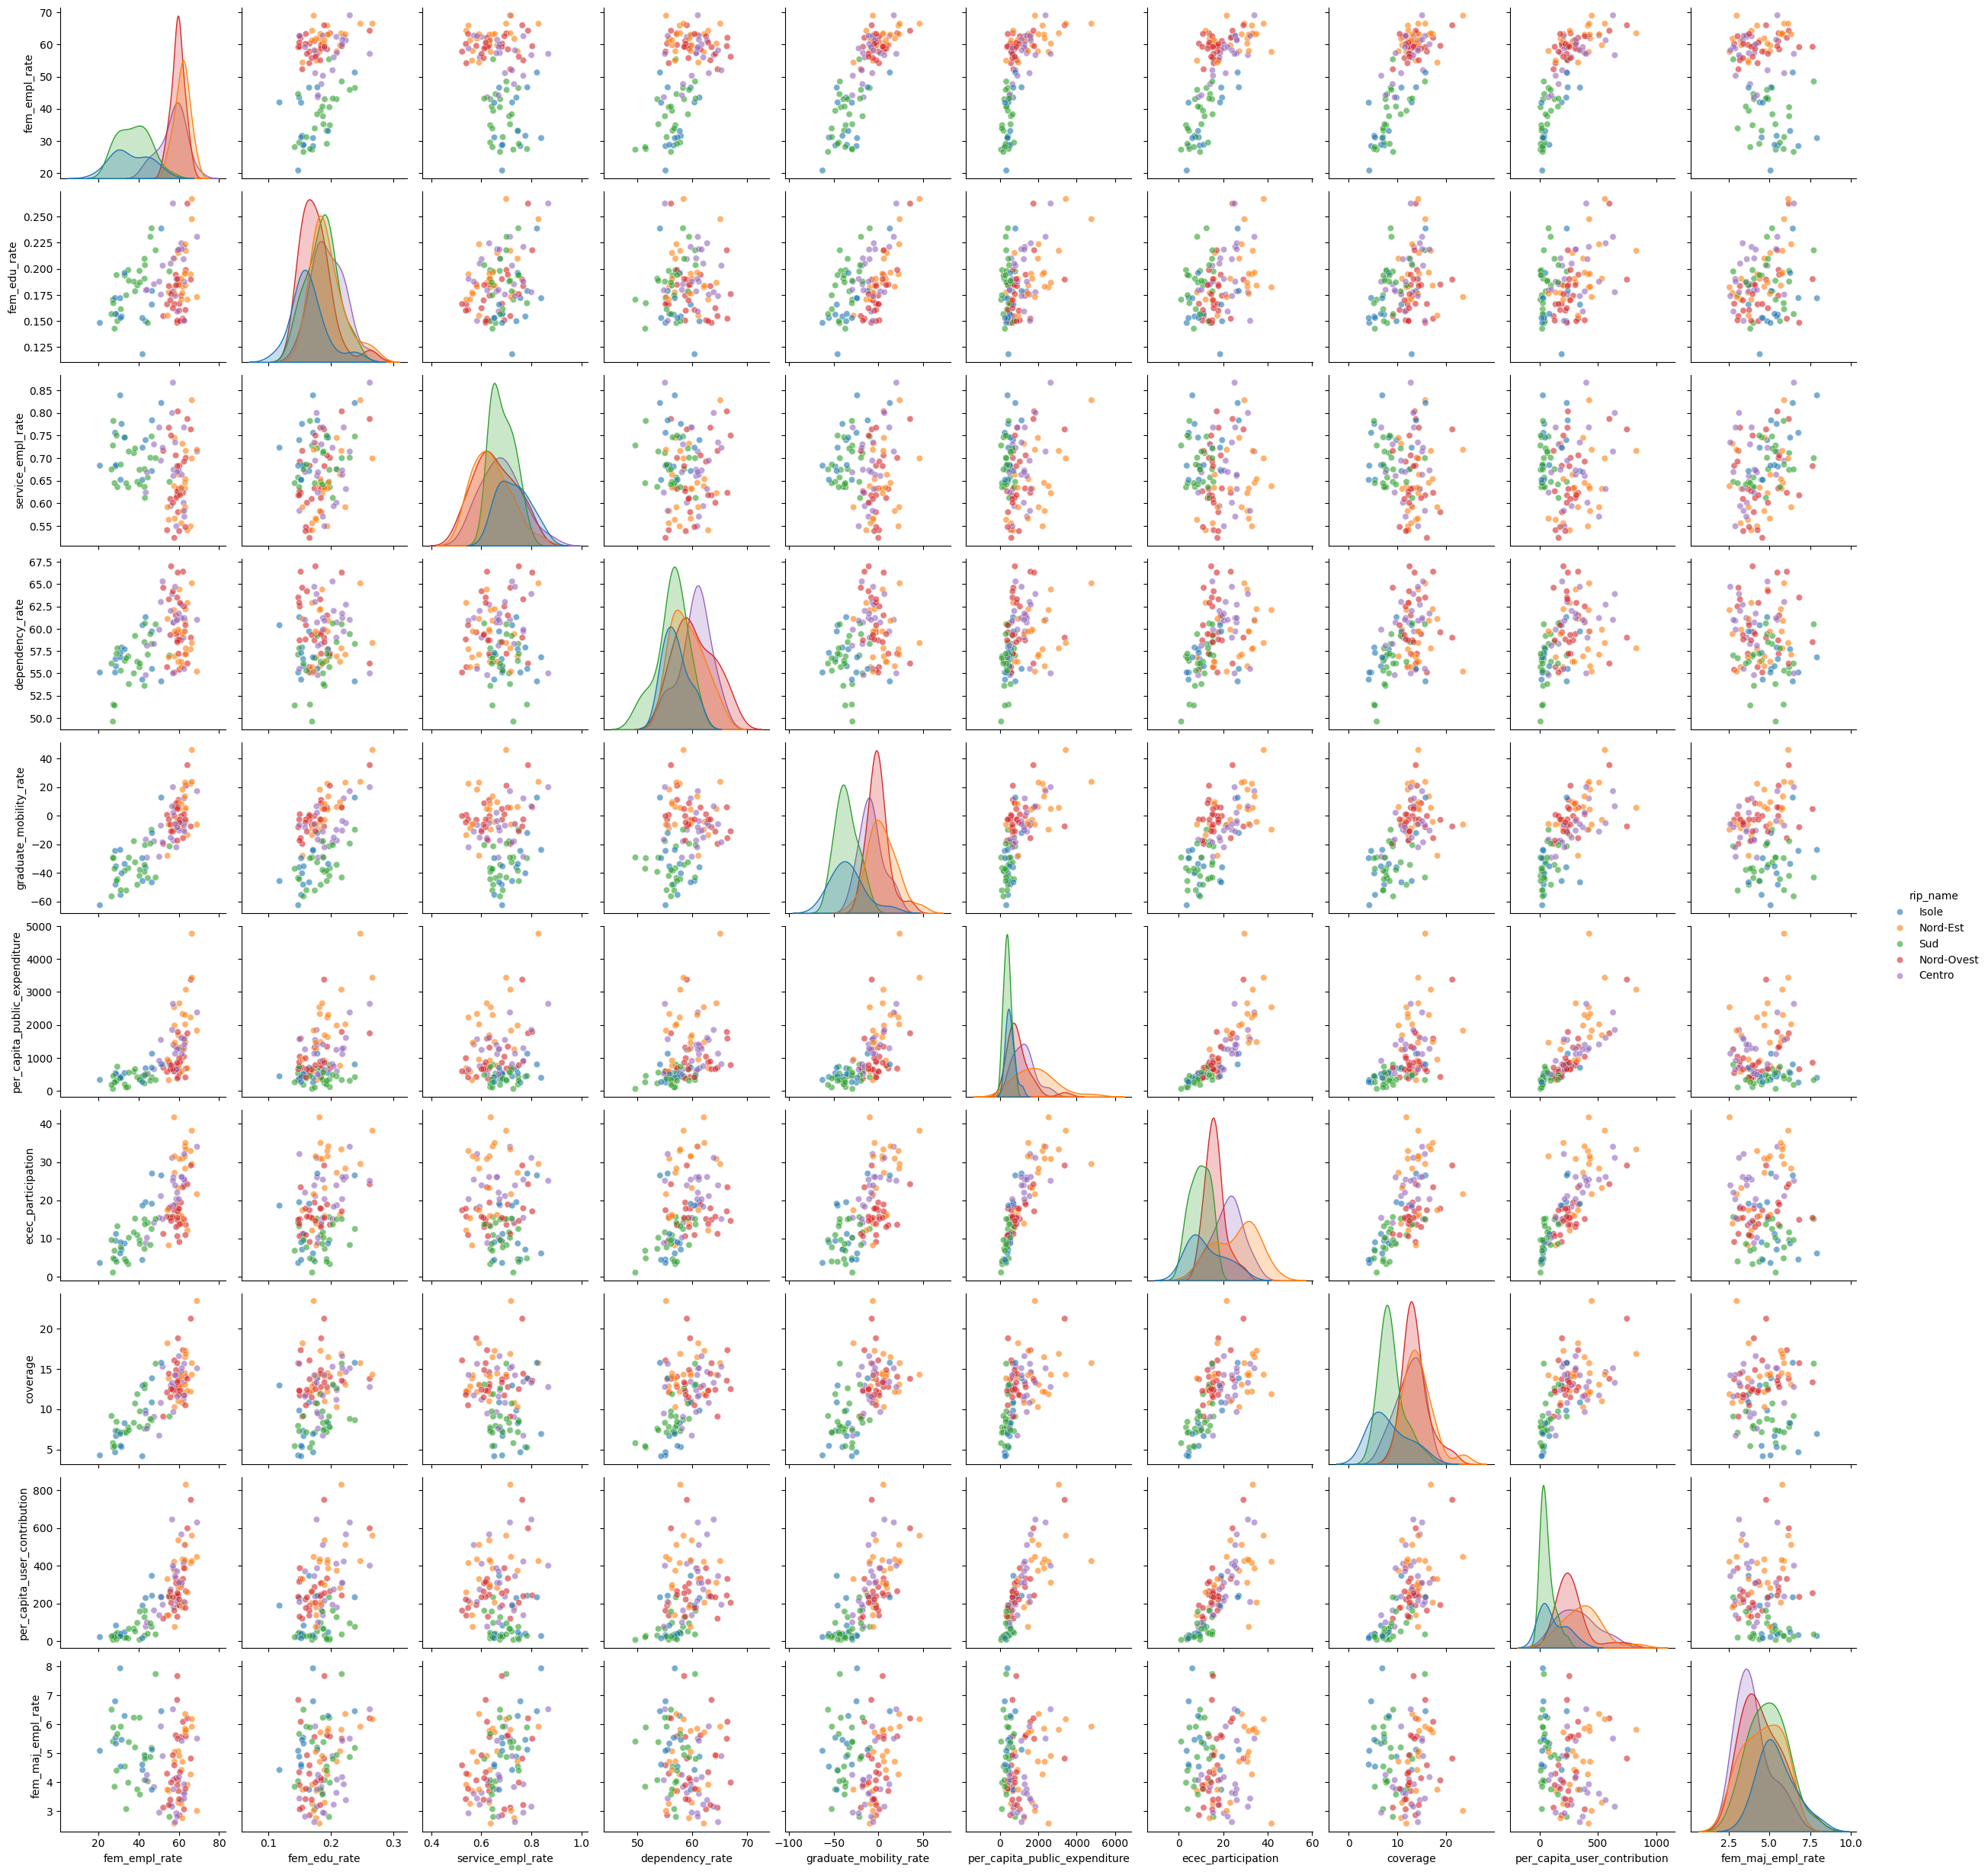

In [ ]:
numeric_cols = gdf_subset.select_dtypes(include='number').columns

sns.pairplot(
    gdf_subset,
    vars=numeric_cols,
    hue='rip_name',  # color by this variable
    plot_kws={'alpha': 0.6}
)
plt.show()

### Check spatial autocollinearity

In [ ]:
gdf_check = gdf_subset.copy()
num_subset = gdf_check.select_dtypes(include='number').columns

# Numeric variable to check
y = gdf_check['fem_empl_rate'].values  

# Create spatial weights (Queen contiguity)
w = libpysal.weights.Queen.from_dataframe(gdf)
w.transform = 'r'  # row-standardized


/tmp/ipykernel_27630/676026199.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)


/home/luca/Projects/Bayesian-Statistics-Project/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [ ]:
for col in num_subset:
    y = gdf_check[col].values
    moran = esda.Moran(y, w)
    print(f"{col}: Moran's I = {moran.I} | p-value = {moran.p_sim}")

fem_empl_rate: Moran's I = 0.8671870880288873 | p-value = 0.001
fem_edu_rate: Moran's I = 0.16445991612883132 | p-value = 0.009
service_empl_rate: Moran's I = 0.18095693561948895 | p-value = 0.006
dependency_rate: Moran's I = 0.5264410836644587 | p-value = 0.001
graduate_mobility_rate: Moran's I = 0.6477011444774634 | p-value = 0.001
per_capita_public_expenditure: Moran's I = 0.5091312510233326 | p-value = 0.001
ecec_participation: Moran's I = 0.691492301259031 | p-value = 0.001
coverage: Moran's I = 0.5680714866113351 | p-value = 0.001
per_capita_user_contribution: Moran's I = 0.5765270515854904 | p-value = 0.001
fem_maj_empl_rate: Moran's I = 0.10057348720296877 | p-value = 0.059


Focusing on our response variable `fem_empl_rate`, I investigate Moran's I clusters

In [ ]:
y = gdf['fem_empl_rate']
w = libpysal.weights.Queen.from_dataframe(gdf, use_index=True)
w.transform = 'r'
lm = esda.Moran_Local(y, w)

/home/luca/Projects/Bayesian-Statistics-Project/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


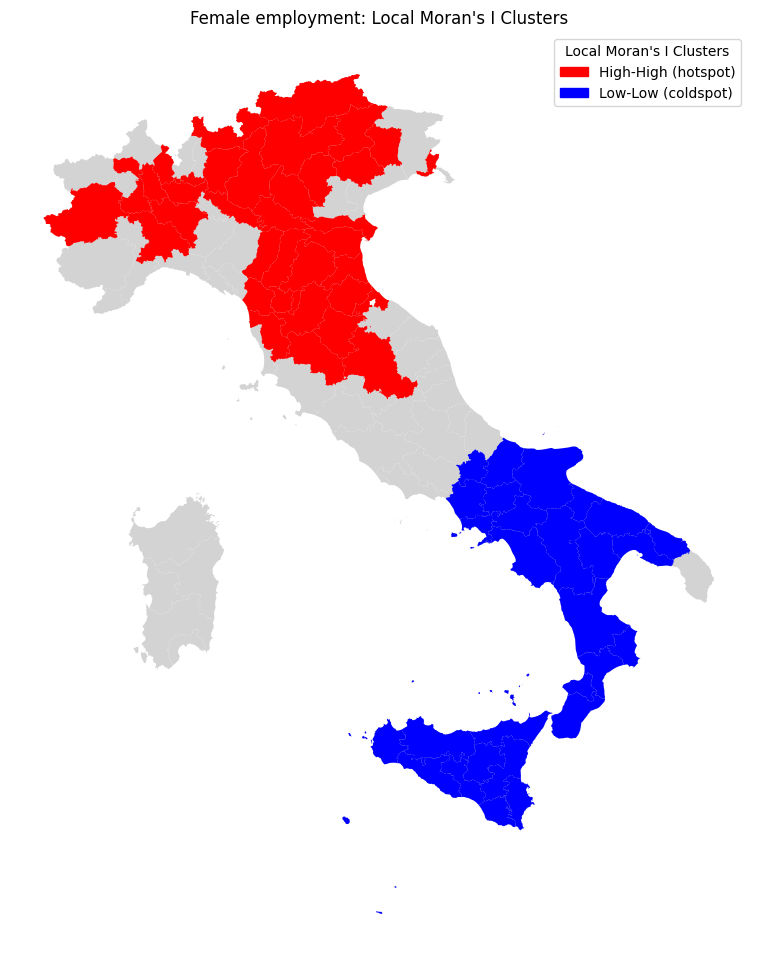

In [ ]:
cluster_colors = {'HH':'red', 'LL':'blue', 'HL':'pink', 'LH':'cyan'}
cluster_labels = {
    'HH': 'High-High (hotspot)',
    'LL': 'Low-Low (coldspot)',
    'HL': 'High-Low (outlier)',
    'LH': 'Low-High (outlier)'
}

# map
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf.plot(color='lightgrey', ax=ax)

for cluster, color in cluster_colors.items():
    subset = gdf[gdf['cluster']==cluster]
    if not subset.empty:
        subset.plot(color=color, ax=ax)

# get the clusters' legend
patches = [mpatches.Patch(color=color, label=cluster_labels[cluster])
           for cluster, color in cluster_colors.items()
           if not gdf[gdf['cluster']==cluster].empty]

plt.legend(handles=patches, title="Local Moran's I Clusters")
ax.set_title("Female employment: Local Moran's I Clusters")
ax.axis('off')
plt.show()